In [207]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [209]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [211]:
print(df.head())
print(df.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [213]:
df.drop('customerID', axis=1, inplace=True)


In [215]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



In [217]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


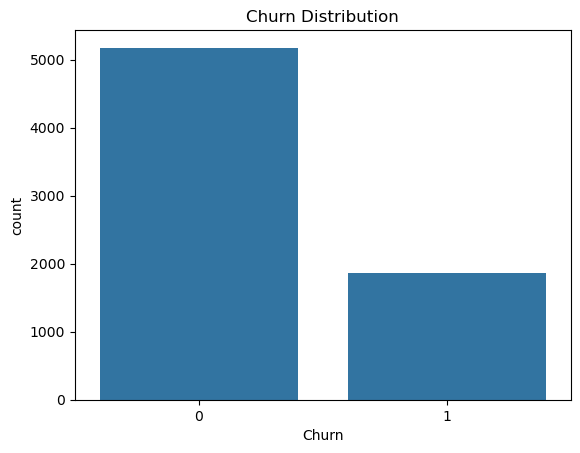

In [219]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


In [233]:
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)
df['is_long_term'] = df['tenure'].apply(lambda x: 1 if x > 24 else 0)


In [235]:
df = pd.get_dummies(df, drop_first=True)


In [237]:
print(df.dtypes)


SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
charges_per_month                        float64
is_long_term                               int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes

In [241]:
X = df.drop('Churn', axis=1)
y = df['Churn']
y.isna().sum()


0

In [243]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,charges_per_month,is_long_term,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,14.925000,0,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,53.985714,1,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,36.050000,0,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,40.016304,1,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,50.550000,0,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [247]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
np.isnan(X_train).sum()


20

In [249]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [251]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [253]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [261]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200)

In [265]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [318]:
from sklearn.metrics import classification_report, roc_auc_score

y_preds = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_preds))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_preds))


Accuracy: 0.8112136266855926
ROC AUC: 0.862071330234869

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [320]:
from sklearn.metrics import classification_report, roc_auc_score

y_preds = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_preds))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_preds))


Accuracy: 0.7991483321504613
ROC AUC: 0.8469249122734379

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [322]:
from sklearn.metrics import classification_report, roc_auc_score

y_preds = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_preds))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_preds))


Accuracy: 0.7863733144073811
ROC AUC: 0.8445273116854886

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.62      0.50      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [277]:
from sklearn.metrics import classification_report, roc_auc_score

preds = xgb.predict(X_test)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.62      0.50      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [324]:
X_cluster = df.drop('Churn', axis=1)


In [326]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_cluster = imputer.fit_transform(X_cluster)


In [328]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_cluster)


In [330]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
segments = kmeans.fit_predict(X_cluster)


In [332]:
df['segment'] = segments


In [338]:
from sklearn.cluster import KMeans 
kmeans = KMeans(n_clusters=4, random_state=42) 
df['segment'] = kmeans.fit_predict(X_cluster)

In [340]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)


In [342]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['segment'] = df['segment']


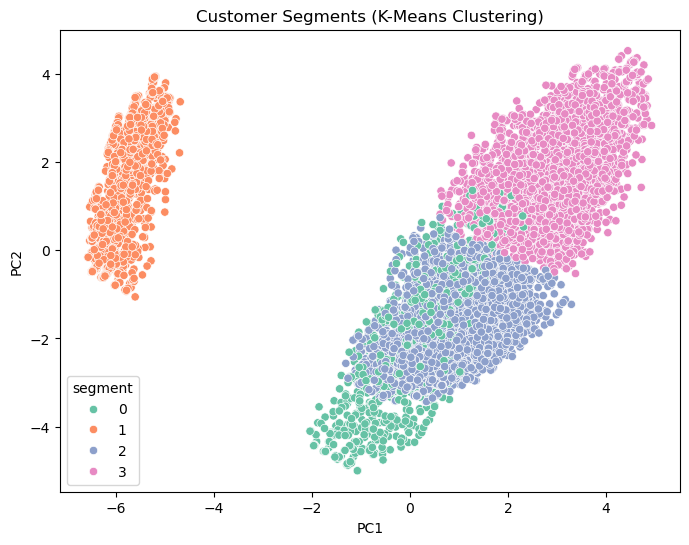

In [344]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='segment',
    palette='Set2',
    data=pca_df
)

plt.title("Customer Segments (K-Means Clustering)")
plt.show()
